# Phase Diagram Analysis: Nonlinear Feature Encoding

When do autoencoders learn nonlinear vs linear encodings as f(n, m, l, S)?

This notebook analyzes the 216-config GPU sweep (4 n × 6 m × 4 l × 3 S, 2772 total seeds) to:
1. Map the phase diagram across the full config space
2. Test theoretical predictions: (1-S)n/m as control parameter, l×log₂(n/m)≈10 boundary
3. Understand what depth buys and where it fails
4. Identify confident vs uncertain regions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
from scipy import stats
import math

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('results_db/compiled/sweep_results.csv')

# Derived columns
df['n_over_m'] = df['n'] / df['m']
df['log_nm'] = np.log2(df['n_over_m'])
df['eff_ratio'] = (1 - df['S']) * df['n'] / df['m']  # Rate-distortion effective ratio
df['cv'] = df['gain_std'] / (df['gain_mean'].abs() + 1e-6)
df['reliable'] = (df['l'] == 1) | (df['cv'] < 0.5)  # Low seed variance
df['mse_improvement'] = (df['mse_linear'] - df['mse_full']) / (df['mse_linear'] + 1e-10)

df_nl = df[df.l >= 2].copy()

n_vals = sorted(df.n.unique())
m_vals = sorted(df.m.unique())
l_vals = sorted(df.l.unique())
S_vals = sorted(df.S.unique())

print(f'Configs: {len(df)} total, {len(df_nl)} nonlinear')
print(f'Reliable nonlinear configs: {df_nl.reliable.sum()} / {len(df_nl)}')
print(f'n/m ratios: {sorted(df.n_over_m.unique())}')
print(f'Effective ratios (1-S)n/m range: [{df.eff_ratio.min():.2f}, {df.eff_ratio.max():.2f}]')

Configs: 216 total, 162 nonlinear
Reliable nonlinear configs: 100 / 162
n/m ratios: [np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0), np.float64(32.0), np.float64(64.0)]
Effective ratios (1-S)n/m range: [0.10, 9.60]


## 1. The Phase Diagram
Nonlinear gain across the full (n, m, l, S) space. Each heatmap cell is one trained autoencoder.

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_32135/242020064.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


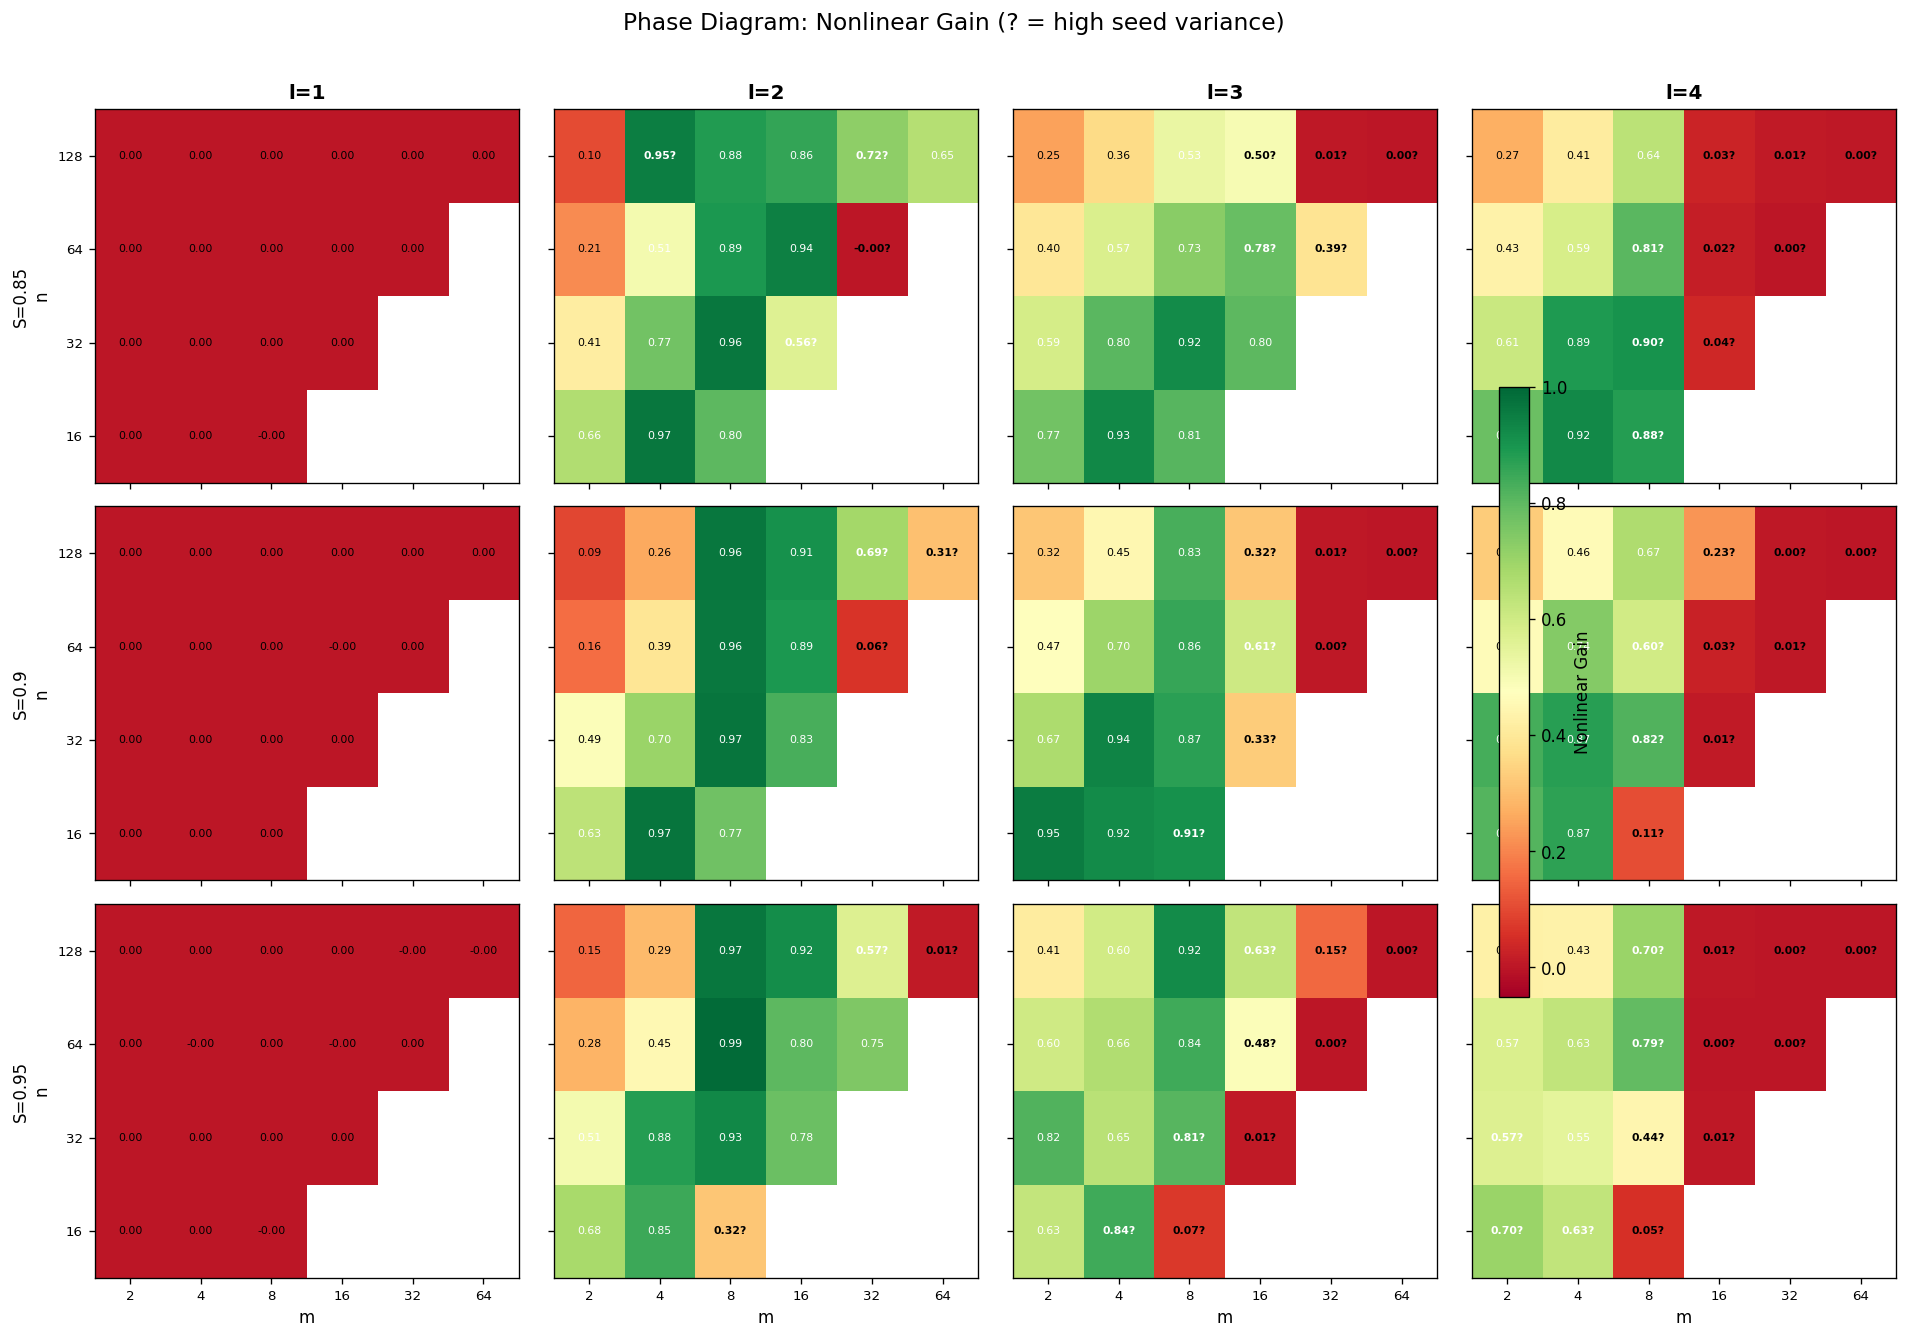

In [2]:
# Full phase diagram: S rows × l columns, each cell is n×m heatmap
fig, axes = plt.subplots(len(S_vals), len(l_vals), figsize=(16, 11),
                          sharex=True, sharey=True)

for i, S in enumerate(S_vals):
    for j, l in enumerate(l_vals):
        ax = axes[i, j]
        sub = df[(df.S == S) & (df.l == l)]
        
        grid = np.full((len(n_vals), len(m_vals)), np.nan)
        reliable_grid = np.full((len(n_vals), len(m_vals)), True)
        for _, row in sub.iterrows():
            ni = n_vals.index(row['n'])
            mi = m_vals.index(row['m'])
            grid[ni, mi] = row['nonlinear_gain']
            reliable_grid[ni, mi] = row['reliable']
        
        im = ax.imshow(grid, cmap='RdYlGn', vmin=-0.05, vmax=1.0,
                       aspect='auto', origin='lower')
        
        # Annotate + mark unreliable with hatching
        for ni, n in enumerate(n_vals):
            for mi, m in enumerate(m_vals):
                if np.isnan(grid[ni, mi]):
                    continue
                val = grid[ni, mi]
                color = 'white' if val > 0.5 else 'black'
                marker = '' if reliable_grid[ni, mi] else '?'
                ax.text(mi, ni, f'{val:.2f}{marker}', ha='center', va='center',
                       fontsize=6.5, color=color, fontweight='bold' if not reliable_grid[ni, mi] else 'normal')
        
        ax.set_xticks(range(len(m_vals)))
        ax.set_xticklabels(m_vals, fontsize=8)
        ax.set_yticks(range(len(n_vals)))
        ax.set_yticklabels(n_vals, fontsize=8)
        if i == 0:
            ax.set_title(f'l={l}', fontsize=12, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'S={S}\nn', fontsize=10)
        if i == len(S_vals) - 1:
            ax.set_xlabel('m', fontsize=10)

fig.suptitle('Phase Diagram: Nonlinear Gain (? = high seed variance)', fontsize=14, y=1.01)
fig.colorbar(im, ax=axes, label='Nonlinear Gain', shrink=0.6, pad=0.02)
plt.tight_layout()
plt.show()

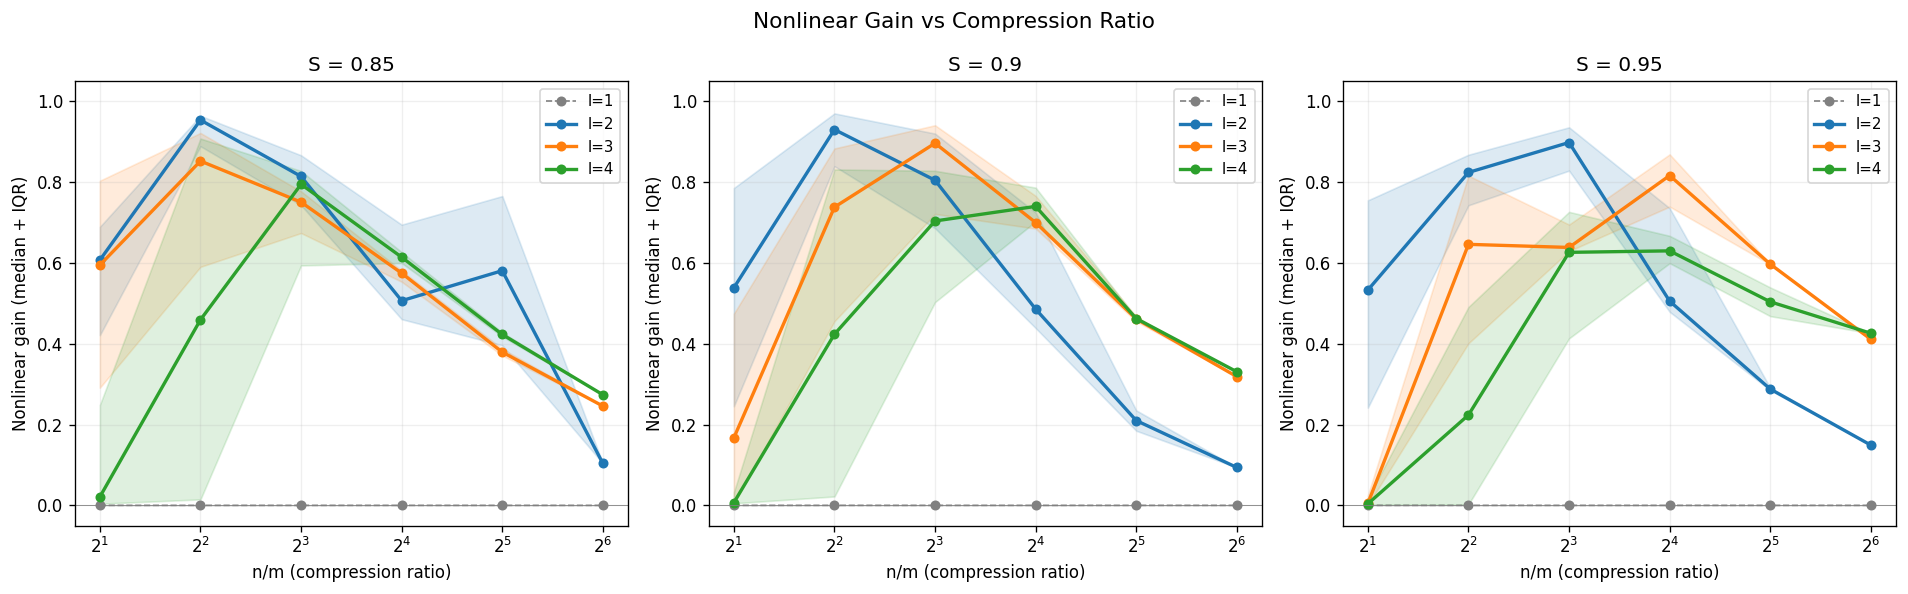

In [3]:
# Collapsed view: gain vs n/m ratio, one line per depth, averaged over S
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for si, S in enumerate(S_vals):
    ax = axes[si]
    ax.set_title(f'S = {S}', fontsize=12)
    
    for l in [1, 2, 3, 4]:
        sub = df[(df.S == S) & (df.l == l)]
        grouped = sub.groupby('n_over_m').agg(
            gain_median=('nonlinear_gain', 'median'),
            gain_q25=('nonlinear_gain', lambda x: x.quantile(0.25)),
            gain_q75=('nonlinear_gain', lambda x: x.quantile(0.75)),
        ).reset_index()
        
        ls = '--' if l == 1 else '-'
        color = 'gray' if l == 1 else f'C{l-2}'
        lw = 1 if l == 1 else 2
        ax.plot(grouped['n_over_m'], grouped['gain_median'], 
               marker='o', ms=5, ls=ls, color=color, lw=lw, label=f'l={l}')
        ax.fill_between(grouped['n_over_m'], grouped['gain_q25'], grouped['gain_q75'],
                       alpha=0.15, color=color)
    
    ax.set_xscale('log', base=2)
    ax.set_xlabel('n/m (compression ratio)')
    ax.set_ylabel('Nonlinear gain (median + IQR)')
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='gray', lw=0.5)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

fig.suptitle('Nonlinear Gain vs Compression Ratio', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Testing Theoretical Predictions

**Rate-distortion theory** predicts the effective compression ratio is **(1-S)n/m**, not n/m alone.

**Previous empirical finding**: Phase boundary at l × log₂(n/m) ≈ 10.

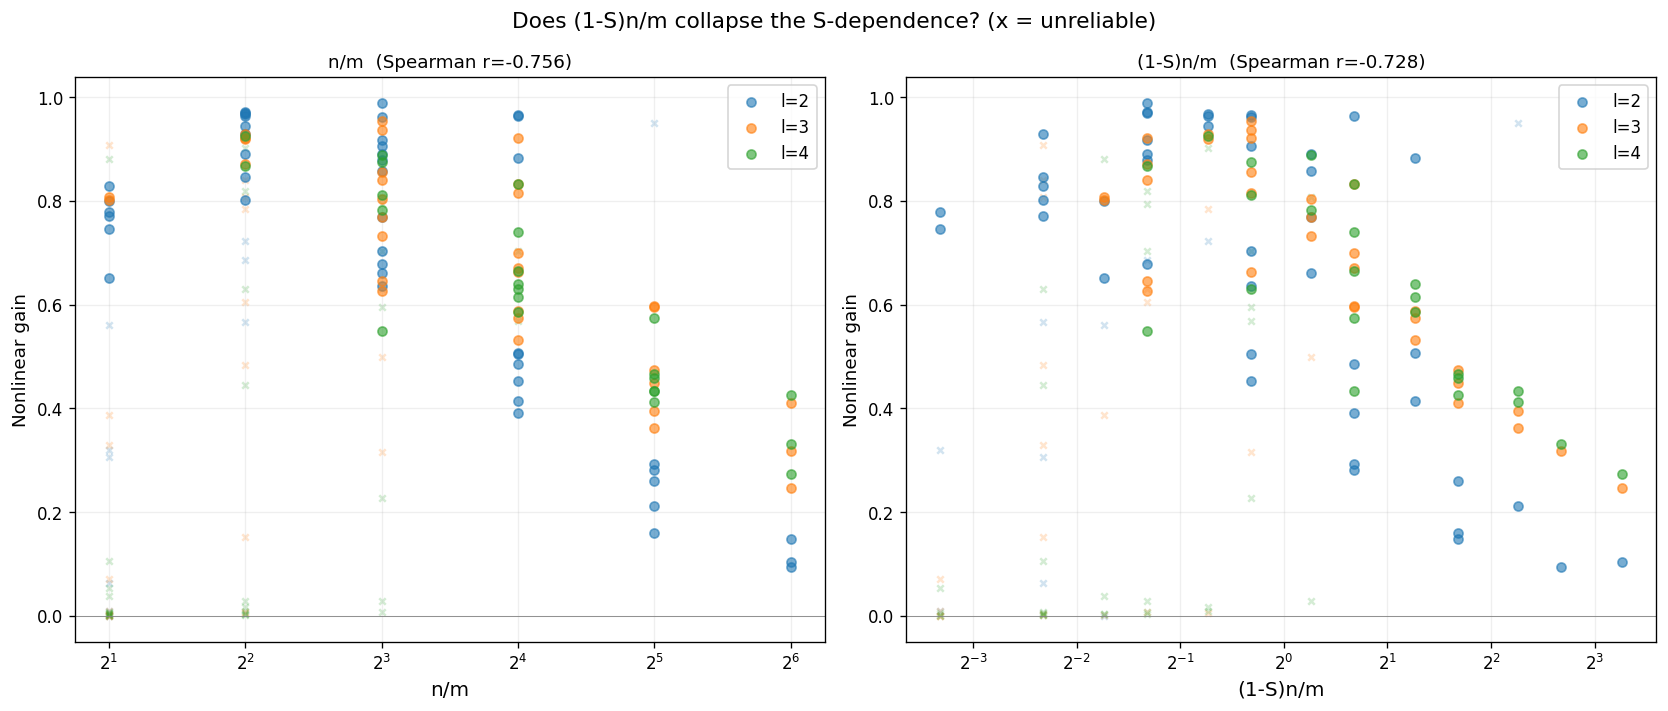

n/m            : Spearman=-0.756, Pearson=-0.805
(1-S)n/m       : Spearman=-0.728, Pearson=-0.744
log₂(n/m)      : Spearman=-0.756, Pearson=-0.773


In [4]:
# Test: does (1-S)n/m collapse the data better than n/m?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_col, x_label in [
    (axes[0], 'n_over_m', 'n/m'),
    (axes[1], 'eff_ratio', '(1-S)n/m'),
]:
    for l in [2, 3, 4]:
        sub = df_nl[df_nl.l == l]
        rel = sub[sub.reliable]
        unrel = sub[~sub.reliable]
        ax.scatter(rel[x_col], rel['nonlinear_gain'], 
                  alpha=0.6, s=30, label=f'l={l}', zorder=3)
        ax.scatter(unrel[x_col], unrel['nonlinear_gain'],
                  alpha=0.2, s=15, marker='x', color=f'C{l-2}')
    
    ax.set_xscale('log', base=2)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel('Nonlinear gain', fontsize=11)
    ax.axhline(0, color='gray', lw=0.5)
    ax.legend()
    ax.grid(alpha=0.2)
    
    # Correlation with gain for reliable configs only
    rel = df_nl[df_nl.reliable]
    r, p = stats.spearmanr(rel[x_col], rel['nonlinear_gain'])
    ax.set_title(f'{x_label}  (Spearman r={r:.3f})', fontsize=11)

fig.suptitle('Does (1-S)n/m collapse the S-dependence? (x = unreliable)', fontsize=13)
plt.tight_layout()
plt.show()

# Quantitative comparison
rel = df_nl[df_nl.reliable]
for x_col, label in [('n_over_m', 'n/m'), ('eff_ratio', '(1-S)n/m'), ('log_nm', 'log₂(n/m)')]:
    r_s, _ = stats.spearmanr(rel[x_col], rel['nonlinear_gain'])
    r_p, _ = stats.pearsonr(rel[x_col], rel['nonlinear_gain'])
    print(f'{label:15s}: Spearman={r_s:.3f}, Pearson={r_p:.3f}')

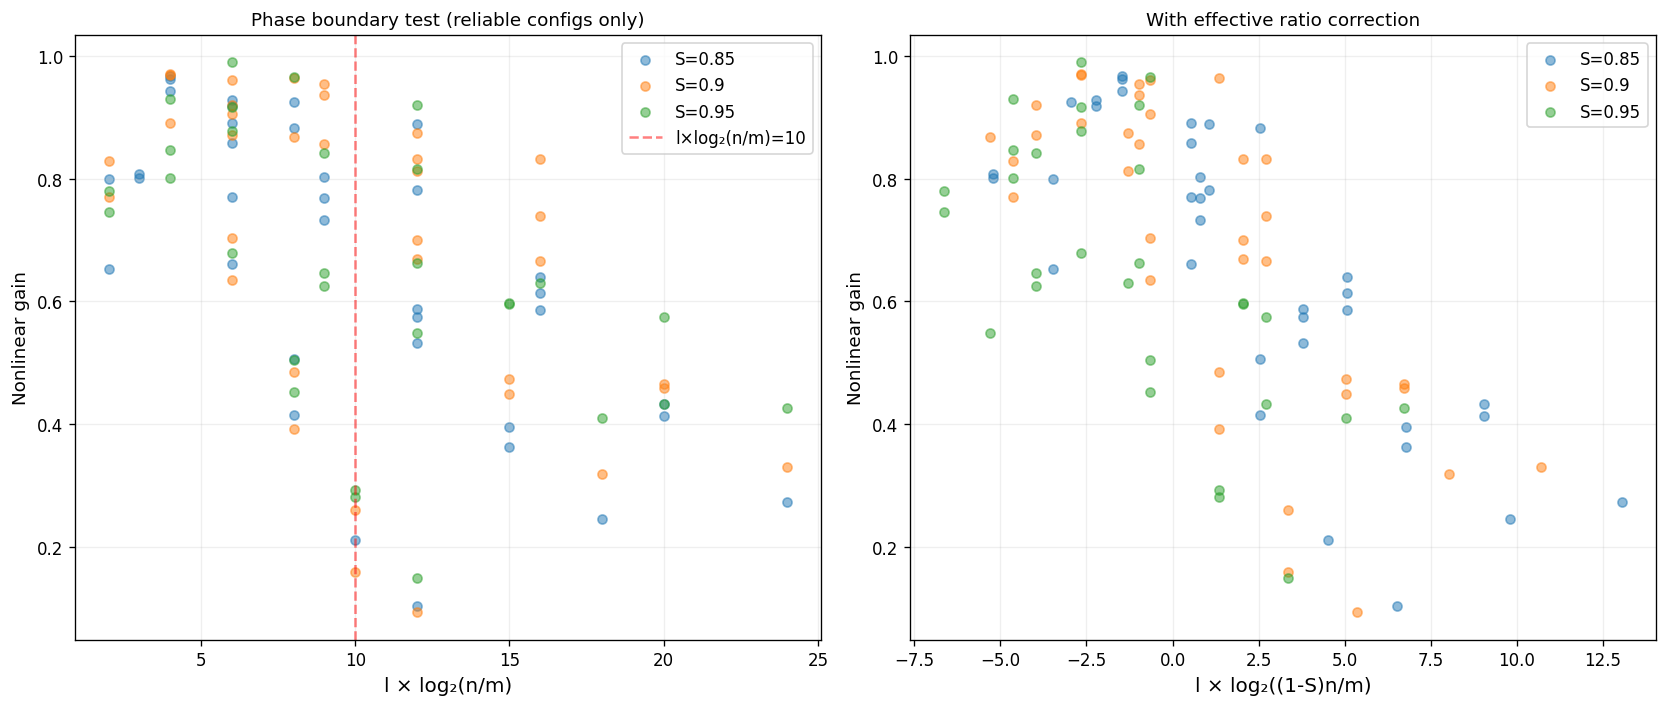

l×log₂(n/m)              : Spearman=-0.597, boundary std=0.104
l×log₂((1-S)n/m)         : Spearman=-0.683, boundary std=0.177


In [5]:
# Test: does l × log₂(n/m) predict the phase boundary?
df_nl = df_nl.copy()
df_nl['l_log_nm'] = df_nl['l'] * df_nl['log_nm']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: l*log₂(n/m) vs gain
ax = axes[0]
for S in S_vals:
    sub = df_nl[df_nl.S == S]
    rel = sub[sub.reliable]
    ax.scatter(rel['l_log_nm'], rel['nonlinear_gain'],
              alpha=0.5, s=30, label=f'S={S}')

ax.axvline(10, color='red', ls='--', alpha=0.5, label='l×log₂(n/m)=10')
ax.set_xlabel('l × log₂(n/m)', fontsize=12)
ax.set_ylabel('Nonlinear gain', fontsize=11)
ax.set_title('Phase boundary test (reliable configs only)', fontsize=11)
ax.legend()
ax.grid(alpha=0.2)

# Same but with (1-S) correction
ax = axes[1]
df_nl['l_log_eff'] = df_nl['l'] * np.log2(df_nl['eff_ratio'].clip(lower=0.1))

for S in S_vals:
    sub = df_nl[df_nl.S == S]
    rel = sub[sub.reliable]
    ax.scatter(rel['l_log_eff'], rel['nonlinear_gain'],
              alpha=0.5, s=30, label=f'S={S}')

ax.set_xlabel('l × log₂((1-S)n/m)', fontsize=12)
ax.set_ylabel('Nonlinear gain', fontsize=11)
ax.set_title('With effective ratio correction', fontsize=11)
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Which collapses better?
rel = df_nl[df_nl.reliable]
for col, label in [('l_log_nm', 'l×log₂(n/m)'), ('l_log_eff', 'l×log₂((1-S)n/m)')]:
    r, _ = stats.spearmanr(rel[col], rel['nonlinear_gain'])
    # Also: how tight is the scatter at the boundary?
    boundary = rel[(rel[col] > 3) & (rel[col] < 8)]
    if len(boundary) > 5:
        boundary_std = boundary['nonlinear_gain'].std()
    else:
        boundary_std = np.nan
    print(f'{label:25s}: Spearman={r:.3f}, boundary std={boundary_std:.3f}')

## 3. What Depth Buys

Does more depth always help? The sweep shows l=4 underperforms l=2 in 63% of configs — is this optimization failure or a real depth penalty?

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_32135/1469297525.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


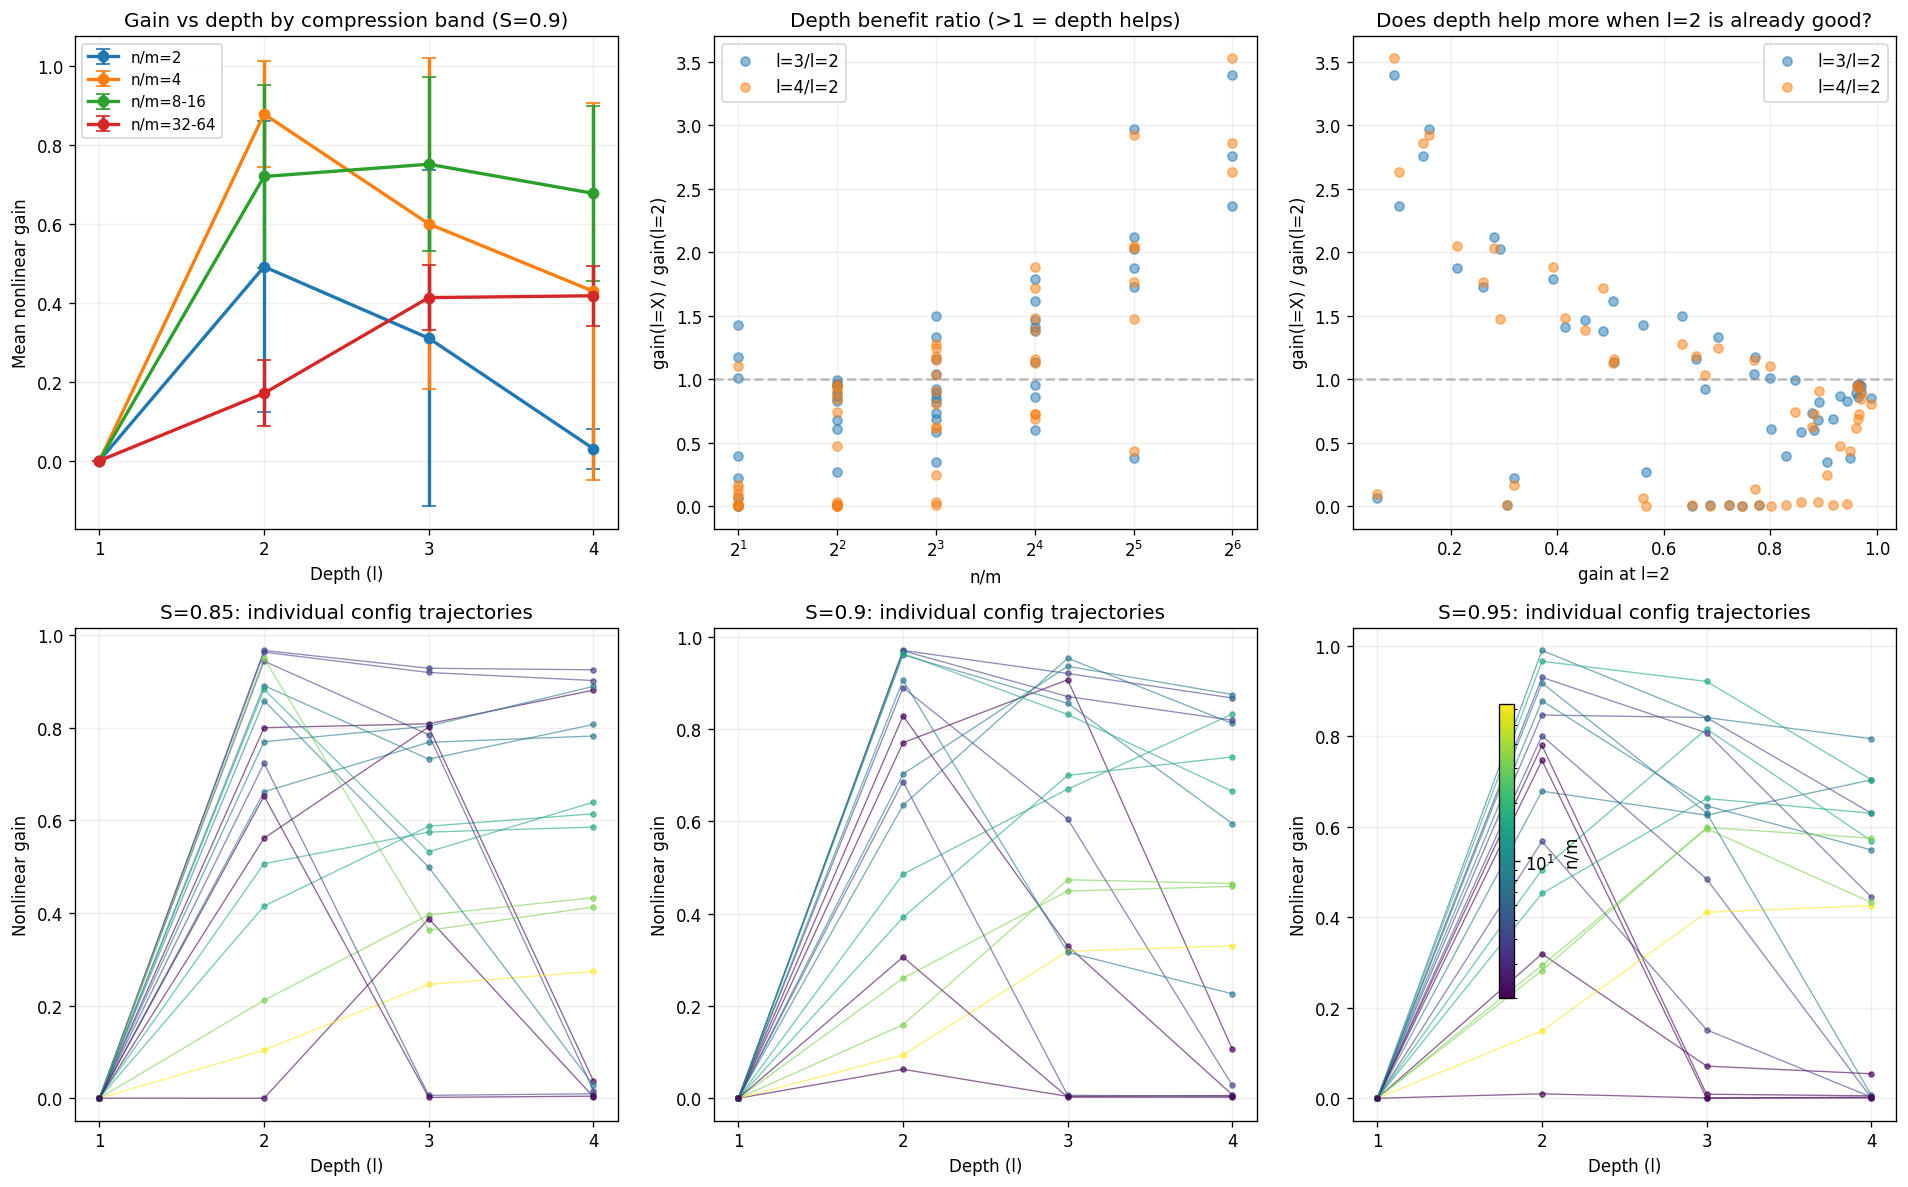

l=3 vs l=2: median ratio=0.94, depth helps in 21/52 configs
l=4 vs l=2: median ratio=0.77, depth helps in 20/52 configs


In [6]:
# For each (n,m,S), plot the gain trajectory across depths
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Top row: gain vs depth, faceted by n/m bands
nm_bands = [(2, 2, 'n/m=2'), (4, 4, 'n/m=4'), (8, 16, 'n/m=8-16'), (32, 64, 'n/m=32-64')]

ax = axes[0, 0]
for nm_lo, nm_hi, label in nm_bands:
    sub = df[(df.n_over_m >= nm_lo) & (df.n_over_m <= nm_hi) & (df.S == 0.9)]
    means = sub.groupby('l')['nonlinear_gain'].mean()
    stds = sub.groupby('l')['nonlinear_gain'].std()
    ax.errorbar(means.index, means.values, yerr=stds.values,
               marker='o', capsize=4, label=label, lw=2)

ax.set_xlabel('Depth (l)')
ax.set_ylabel('Mean nonlinear gain')
ax.set_title('Gain vs depth by compression band (S=0.9)')
ax.set_xticks([1, 2, 3, 4])
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# Gain ratio: l=X / l=2 for each (n,m,S)
ax = axes[0, 1]
depth_ratios = []
for (n, m, S), grp in df.groupby(['n', 'm', 'S']):
    g2 = grp[grp.l == 2]['nonlinear_gain'].values
    if len(g2) == 0 or g2[0] < 0.05:
        continue
    for l in [3, 4]:
        gl = grp[grp.l == l]['nonlinear_gain'].values
        if len(gl) > 0:
            depth_ratios.append({'n': n, 'm': m, 'S': S, 'l': l, 
                                'n_over_m': n/m, 'ratio': gl[0] / g2[0],
                                'gain_l2': g2[0], 'gain_lx': gl[0]})

dr = pd.DataFrame(depth_ratios)
for l in [3, 4]:
    sub = dr[dr.l == l]
    ax.scatter(sub['n_over_m'], sub['ratio'], alpha=0.5, s=30, label=f'l={l}/l=2')

ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xscale('log', base=2)
ax.set_xlabel('n/m')
ax.set_ylabel('gain(l=X) / gain(l=2)')
ax.set_title('Depth benefit ratio (>1 = depth helps)')
ax.legend()
ax.grid(alpha=0.2)

# Where does depth help most?
ax = axes[0, 2]
for l in [3, 4]:
    sub = dr[dr.l == l]
    ax.scatter(sub['gain_l2'], sub['ratio'], alpha=0.5, s=30, label=f'l={l}/l=2')

ax.axhline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('gain at l=2')
ax.set_ylabel('gain(l=X) / gain(l=2)')
ax.set_title('Does depth help more when l=2 is already good?')
ax.legend()
ax.grid(alpha=0.2)

# Bottom row: individual (n,m) trajectories across depth
for si, S in enumerate(S_vals):
    ax = axes[1, si]
    ax.set_title(f'S={S}: individual config trajectories')
    
    cmap = plt.cm.viridis
    nm_unique = sorted(df.n_over_m.unique())
    norm = mcolors.LogNorm(vmin=min(nm_unique), vmax=max(nm_unique))
    
    for (n, m), grp in df[df.S == S].groupby(['n', 'm']):
        grp = grp.sort_values('l')
        color = cmap(norm(n/m))
        # Bold unreliable segments
        ax.plot(grp['l'], grp['nonlinear_gain'], 
               marker='o', ms=3, color=color, alpha=0.6, lw=0.8)
    
    ax.set_xlabel('Depth (l)')
    ax.set_ylabel('Nonlinear gain')
    ax.set_xticks([1, 2, 3, 4])
    ax.grid(alpha=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes[1, :], label='n/m', shrink=0.7, pad=0.02)
plt.tight_layout()
plt.show()

# Summary stats
for l in [3, 4]:
    sub = dr[dr.l == l]
    print(f'l={l} vs l=2: median ratio={sub["ratio"].median():.2f}, '
          f'depth helps in {(sub["ratio"] >= 1).sum()}/{len(sub)} configs')

## 4. The Linearity-Gain Relationship

Linearity score measures how well the encoder is approximated by a linear map. High gain with high linearity = "write linear, read nonlinear" strategy.

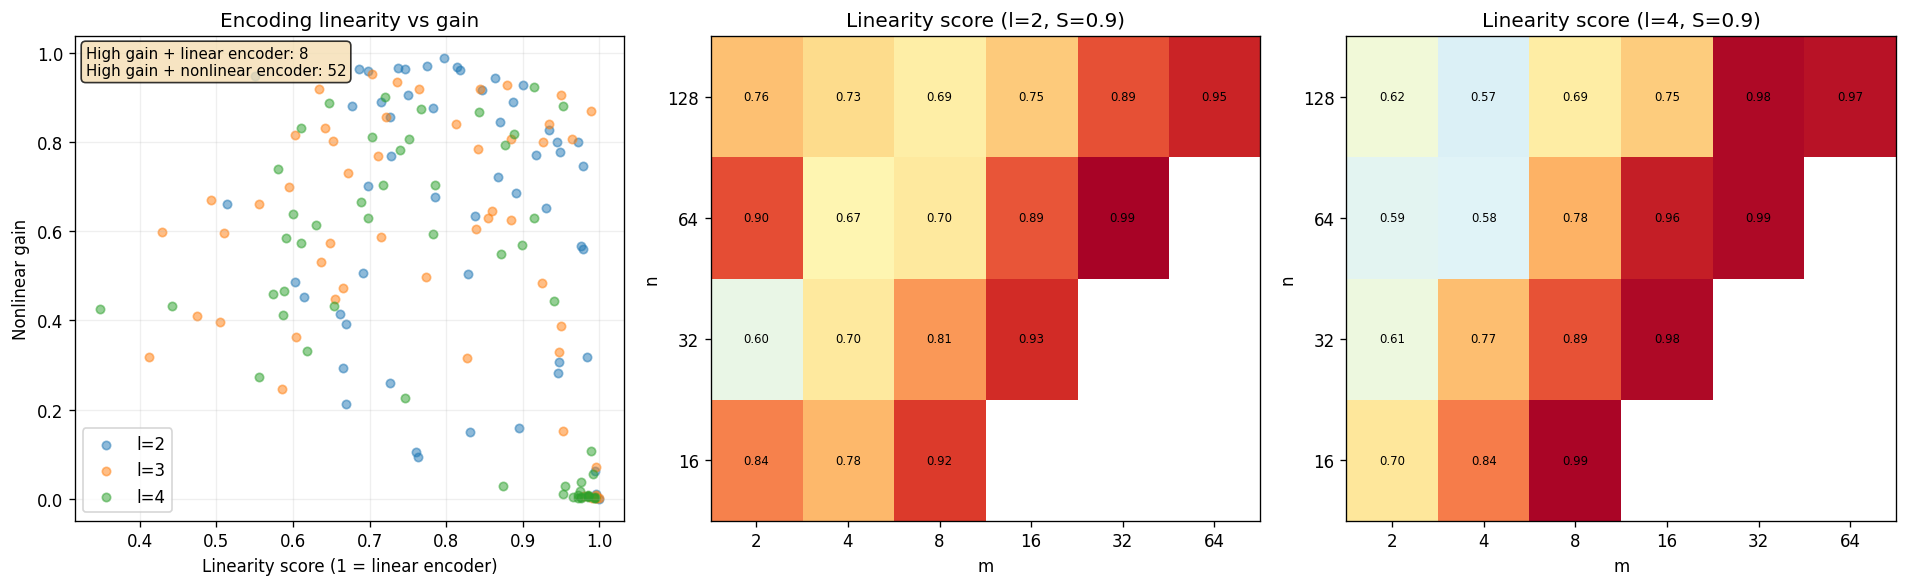

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter: linearity vs gain
ax = axes[0]
for l in [2, 3, 4]:
    sub = df_nl[df_nl.l == l]
    ax.scatter(sub['linearity_score'], sub['nonlinear_gain'],
              alpha=0.5, s=25, label=f'l={l}')

ax.set_xlabel('Linearity score (1 = linear encoder)')
ax.set_ylabel('Nonlinear gain')
ax.set_title('Encoding linearity vs gain')
ax.legend()
ax.grid(alpha=0.2)

# Key question: can you get high gain with high linearity?
high_gain_linear = df_nl[(df_nl.nonlinear_gain > 0.5) & (df_nl.linearity_score > 0.95)]
high_gain_nonlinear = df_nl[(df_nl.nonlinear_gain > 0.5) & (df_nl.linearity_score < 0.8)]
ax.text(0.02, 0.98, 
       f'High gain + linear encoder: {len(high_gain_linear)}\n'
       f'High gain + nonlinear encoder: {len(high_gain_nonlinear)}',
       transform=ax.transAxes, va='top', fontsize=9,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Linearity score heatmap at S=0.9
for j, l in enumerate([2, 4]):
    ax = axes[j + 1]
    sub = df[(df.S == 0.9) & (df.l == l)]
    
    grid = np.full((len(n_vals), len(m_vals)), np.nan)
    for _, row in sub.iterrows():
        ni = n_vals.index(row['n'])
        mi = m_vals.index(row['m'])
        grid[ni, mi] = row['linearity_score']
    
    im = ax.imshow(grid, cmap='RdYlBu_r', vmin=0.3, vmax=1.0,
                   aspect='auto', origin='lower')
    for ni, n in enumerate(n_vals):
        for mi, m in enumerate(m_vals):
            if not np.isnan(grid[ni, mi]):
                ax.text(mi, ni, f'{grid[ni, mi]:.2f}', ha='center', va='center', fontsize=7)
    
    ax.set_xticks(range(len(m_vals)))
    ax.set_xticklabels(m_vals)
    ax.set_yticks(range(len(n_vals)))
    ax.set_yticklabels(n_vals)
    ax.set_xlabel('m')
    ax.set_ylabel('n')
    ax.set_title(f'Linearity score (l={l}, S=0.9)')

plt.tight_layout()
plt.show()

## 5. MSE Landscape
How does reconstruction error behave across the config space? Is nonlinear gain concentrated where MSE is high (hard problems) or evenly distributed?

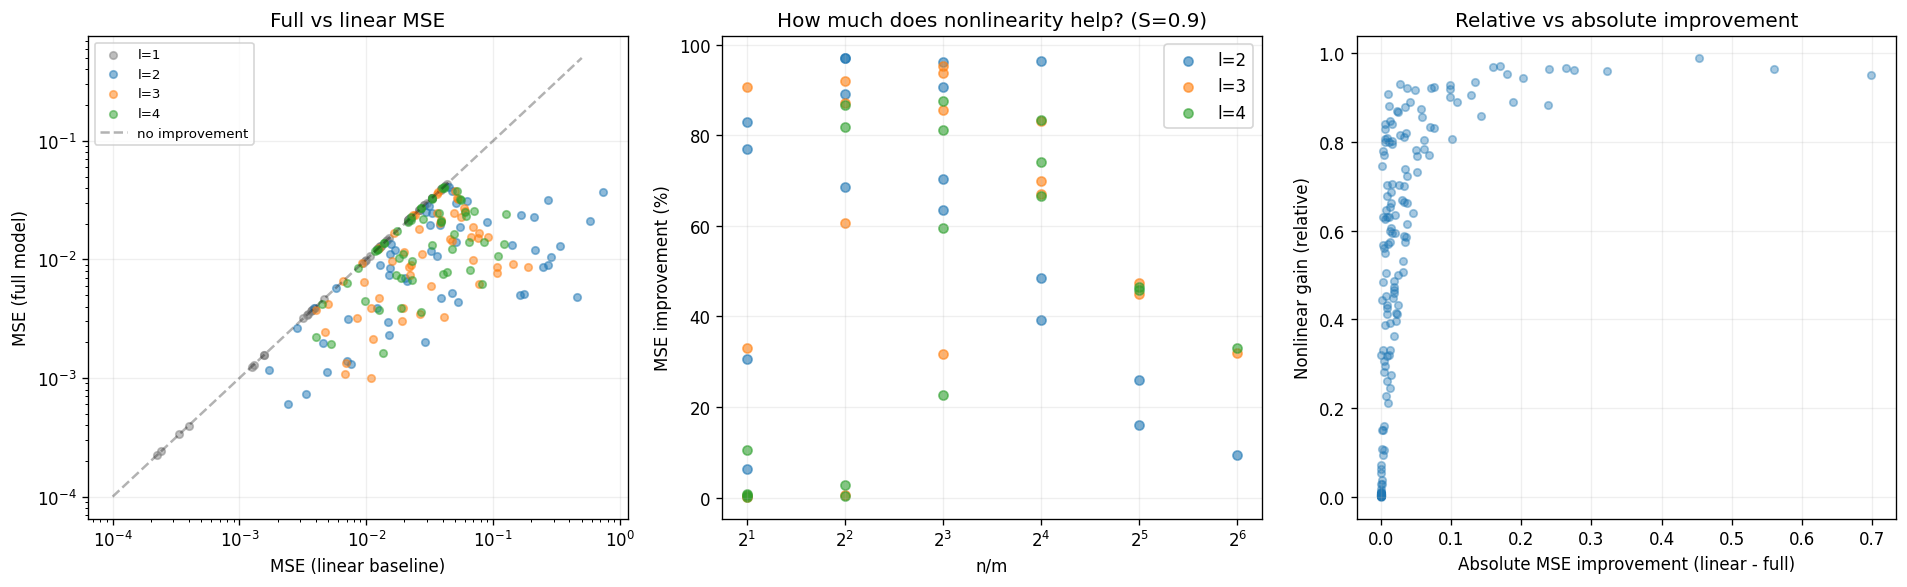

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE_full vs MSE_linear scatter
ax = axes[0]
for l in [1, 2, 3, 4]:
    sub = df[df.l == l]
    color = 'gray' if l == 1 else f'C{l-2}'
    ax.scatter(sub['mse_linear'], sub['mse_full'], alpha=0.5, s=20,
              color=color, label=f'l={l}')

lims = [1e-4, 0.5]
ax.plot(lims, lims, 'k--', alpha=0.3, label='no improvement')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('MSE (linear baseline)')
ax.set_ylabel('MSE (full model)')
ax.set_title('Full vs linear MSE')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# MSE improvement vs compression ratio
ax = axes[1]
for l in [2, 3, 4]:
    sub = df_nl[(df_nl.l == l) & (df_nl.S == 0.9)]
    ax.scatter(sub['n_over_m'], sub['mse_improvement'] * 100,
              alpha=0.6, s=30, label=f'l={l}')

ax.set_xscale('log', base=2)
ax.set_xlabel('n/m')
ax.set_ylabel('MSE improvement (%)')
ax.set_title('How much does nonlinearity help? (S=0.9)')
ax.legend()
ax.grid(alpha=0.2)

# MSE vs gain — is gain just a proxy for absolute MSE improvement?
ax = axes[2]
mse_gap = df_nl['mse_linear'] - df_nl['mse_full']
ax.scatter(mse_gap, df_nl['nonlinear_gain'], alpha=0.4, s=20)
ax.set_xlabel('Absolute MSE improvement (linear - full)')
ax.set_ylabel('Nonlinear gain (relative)')
ax.set_title('Relative vs absolute improvement')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 6. The Phase Boundary
Where exactly does the transition from linear to nonlinear encoding happen? Can we fit the boundary?

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_32135/2837537702.py:33: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sub['log_nm'], sub['l'],


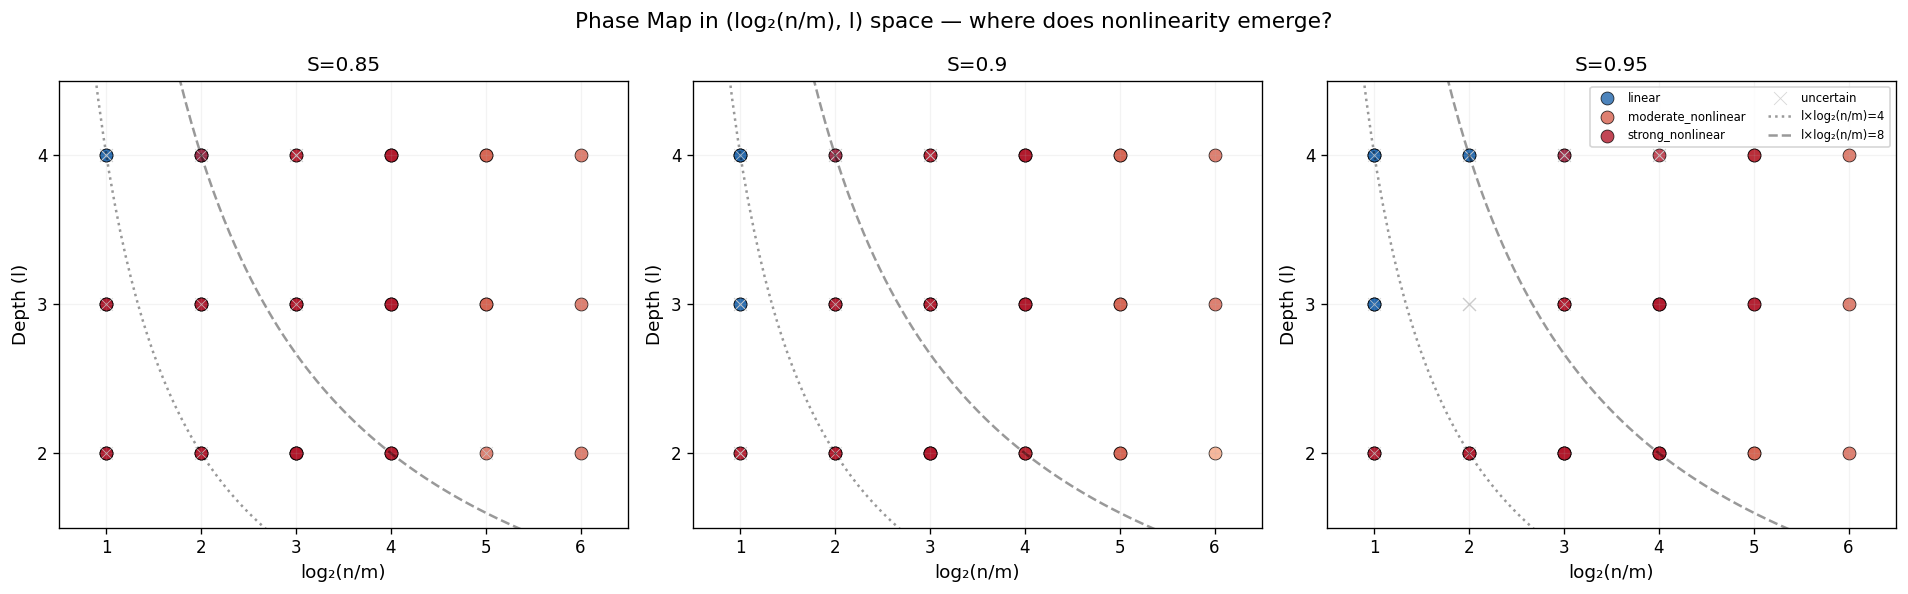

Phase distribution (l≥2):
phase
strong_nonlinear      73
uncertain             38
moderate_nonlinear    26
linear                24
transition             1


In [9]:
# Classify each config into phases
def classify_phase(gain, reliable):
    if gain < 0.02:
        return 'linear'
    elif gain < 0.1:
        return 'transition' if reliable else 'uncertain'
    elif gain < 0.5:
        return 'moderate_nonlinear' if reliable else 'uncertain'
    else:
        return 'strong_nonlinear' if reliable else 'uncertain'

df_nl['phase'] = df_nl.apply(lambda r: classify_phase(r['nonlinear_gain'], r['reliable']), axis=1)

phase_colors = {
    'linear': '#2166ac',
    'transition': '#f4a582',
    'moderate_nonlinear': '#d6604d', 
    'strong_nonlinear': '#b2182b',
    'uncertain': '#cccccc',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for si, S in enumerate(S_vals):
    ax = axes[si]
    ax.set_title(f'S={S}', fontsize=12)
    
    for phase, color in phase_colors.items():
        sub = df_nl[(df_nl.S == S) & (df_nl.phase == phase)]
        if len(sub) == 0:
            continue
        marker = 'x' if phase == 'uncertain' else 'o'
        ax.scatter(sub['log_nm'], sub['l'],
                  c=color, s=60, alpha=0.8, label=phase, marker=marker,
                  edgecolors='black' if phase != 'uncertain' else 'none', linewidths=0.5)
    
    # Draw approximate boundary: l*log₂(n/m) = C
    x_range = np.linspace(0.8, 6.5, 100)
    for C, ls in [(4, ':'), (8, '--')]:
        ax.plot(x_range, C / x_range, color='black', ls=ls, alpha=0.4, lw=1.5,
               label=f'l×log₂(n/m)={C}')
    
    ax.set_xlabel('log₂(n/m)', fontsize=11)
    ax.set_ylabel('Depth (l)', fontsize=11)
    ax.set_yticks([2, 3, 4])
    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(1.5, 4.5)
    ax.grid(alpha=0.15)
    if si == 2:
        ax.legend(fontsize=7, loc='upper right', ncol=2)

fig.suptitle('Phase Map in (log₂(n/m), l) space — where does nonlinearity emerge?', fontsize=13)
plt.tight_layout()
plt.show()

# Phase counts
print('Phase distribution (l≥2):')
print(df_nl.groupby('phase').size().sort_values(ascending=False).to_string())

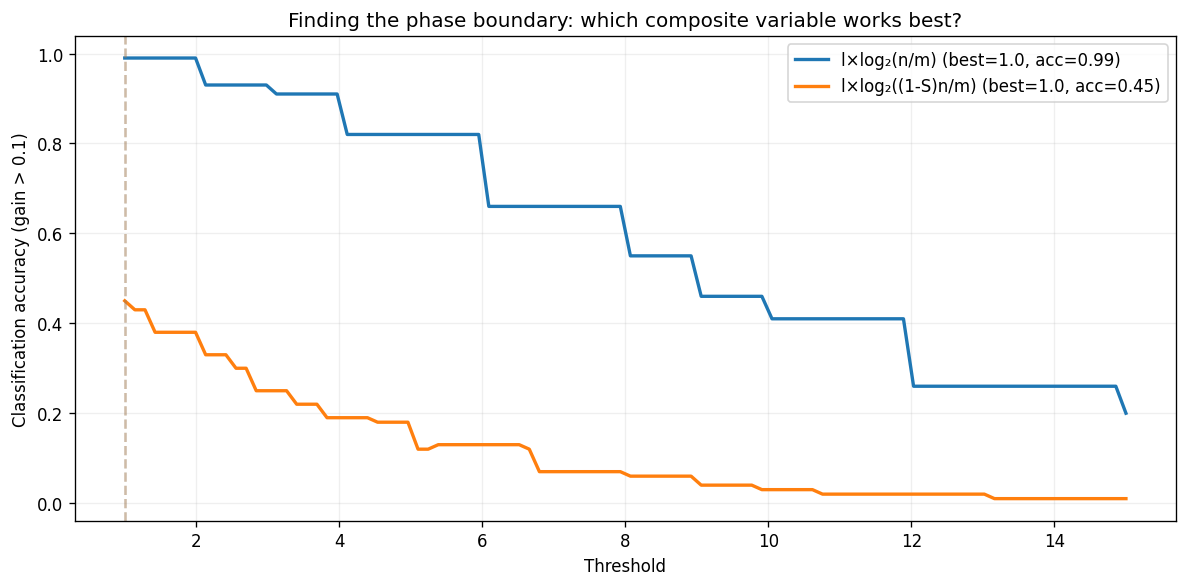

Best boundary with l×log₂(n/m): threshold=1.0, accuracy=99.0%
Best boundary with l×log₂((1-S)n/m): threshold=1.0, accuracy=45.0%


In [10]:
# Fit the phase boundary more precisely
# Use reliable configs, define boundary as gain ∈ [0.1, 0.5]
# In the space l*log₂(n/m), what value best separates low and high gain?

rel = df_nl[df_nl.reliable].copy()
rel['composite'] = rel['l'] * rel['log_nm']

# ROC-like analysis: sweep threshold on composite, classify gain > 0.1
thresholds = np.linspace(1, 15, 100)
accuracies = []
for t in thresholds:
    pred_nonlinear = rel['composite'] > t
    actual_nonlinear = rel['nonlinear_gain'] > 0.1
    acc = (pred_nonlinear == actual_nonlinear).mean()
    accuracies.append(acc)

best_t = thresholds[np.argmax(accuracies)]
best_acc = max(accuracies)

# Also try with effective ratio
rel['composite_eff'] = rel['l'] * np.log2(rel['eff_ratio'].clip(lower=0.1))
accs_eff = []
for t in thresholds:
    pred = rel['composite_eff'] > t
    actual = rel['nonlinear_gain'] > 0.1
    accs_eff.append((pred == actual).mean())

best_t_eff = thresholds[np.argmax(accs_eff)]
best_acc_eff = max(accs_eff)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, accuracies, label=f'l×log₂(n/m) (best={best_t:.1f}, acc={best_acc:.2f})', lw=2)
ax.plot(thresholds, accs_eff, label=f'l×log₂((1-S)n/m) (best={best_t_eff:.1f}, acc={best_acc_eff:.2f})', lw=2)
ax.axvline(best_t, color='C0', ls='--', alpha=0.3)
ax.axvline(best_t_eff, color='C1', ls='--', alpha=0.3)
ax.set_xlabel('Threshold')
ax.set_ylabel('Classification accuracy (gain > 0.1)')
ax.set_title('Finding the phase boundary: which composite variable works best?')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Best boundary with l×log₂(n/m): threshold={best_t:.1f}, accuracy={best_acc:.1%}')
print(f'Best boundary with l×log₂((1-S)n/m): threshold={best_t_eff:.1f}, accuracy={best_acc_eff:.1%}')

## 7. Sparsity Effects
How does S shift the phase diagram? Rate-distortion theory predicts higher S should move the boundary toward lower n/m.

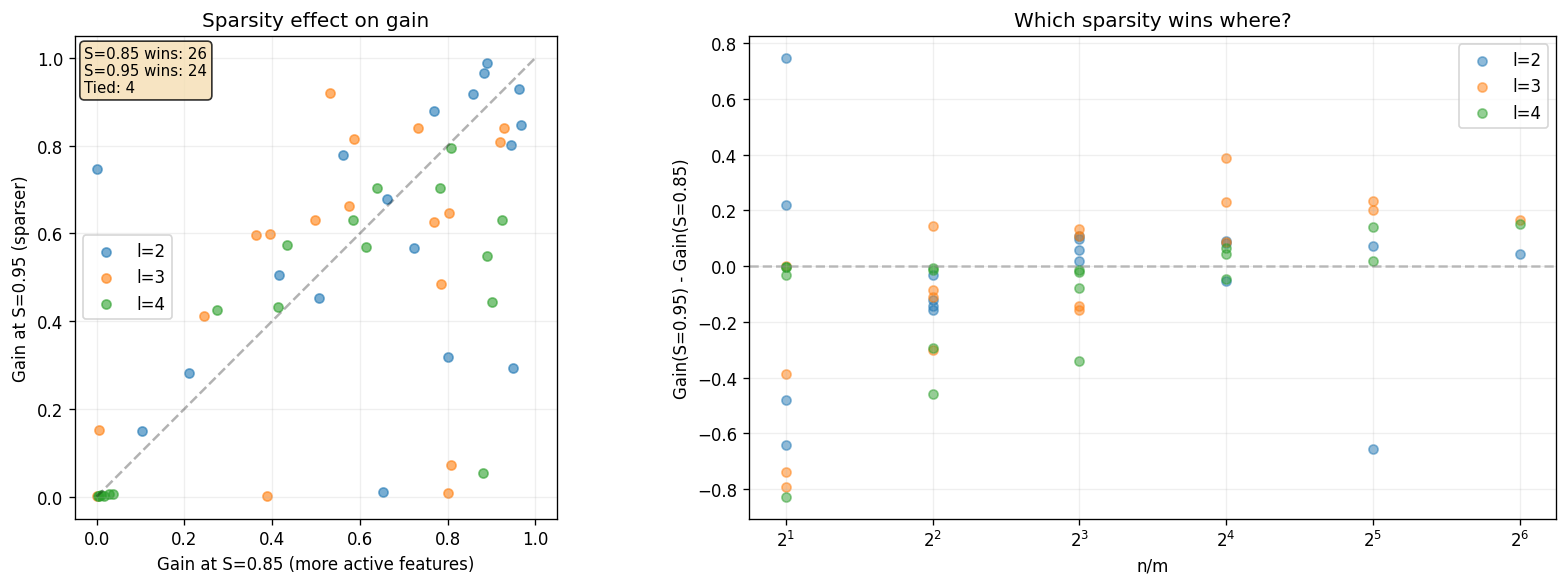

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Direct comparison: gain at S=0.85 vs S=0.95 for same (n,m,l)
ax = axes[0]
pairs = []
for (n, m, l), grp in df_nl.groupby(['n', 'm', 'l']):
    g85 = grp[grp.S == 0.85]['nonlinear_gain'].values
    g95 = grp[grp.S == 0.95]['nonlinear_gain'].values
    if len(g85) > 0 and len(g95) > 0:
        pairs.append({'n': n, 'm': m, 'l': l, 'g85': g85[0], 'g95': g95[0]})

dp = pd.DataFrame(pairs)
colors = [f'C{l-2}' for l in dp['l']]
for l in [2, 3, 4]:
    sub = dp[dp.l == l]
    ax.scatter(sub['g85'], sub['g95'], alpha=0.6, s=30, label=f'l={l}')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Gain at S=0.85 (more active features)')
ax.set_ylabel('Gain at S=0.95 (sparser)')
ax.set_title('Sparsity effect on gain')
ax.legend()
ax.grid(alpha=0.2)
ax.set_aspect('equal')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

above = (dp['g95'] > dp['g85'] + 0.01).sum()
below = (dp['g85'] > dp['g95'] + 0.01).sum()
ax.text(0.02, 0.98, f'S=0.85 wins: {below}\nS=0.95 wins: {above}\nTied: {len(dp)-above-below}',
       transform=ax.transAxes, va='top', fontsize=9,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Gain shift: for each (n,m,l), how does gain change from S=0.85 to S=0.95?
ax = axes[1]
dp['gain_shift'] = dp['g95'] - dp['g85']
dp['nm'] = dp['n'] / dp['m']

for l in [2, 3, 4]:
    sub = dp[dp.l == l]
    ax.scatter(sub['nm'], sub['gain_shift'], alpha=0.5, s=30, label=f'l={l}')

ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xscale('log', base=2)
ax.set_xlabel('n/m')
ax.set_ylabel('Gain(S=0.95) - Gain(S=0.85)')
ax.set_title('Which sparsity wins where?')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 8. Confidence Map
Which regions of the phase diagram do we trust, and where should we retrain?

/var/folders/y4/js36xx5s243220sv2my43_pm0000gn/T/ipykernel_32135/3419259748.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


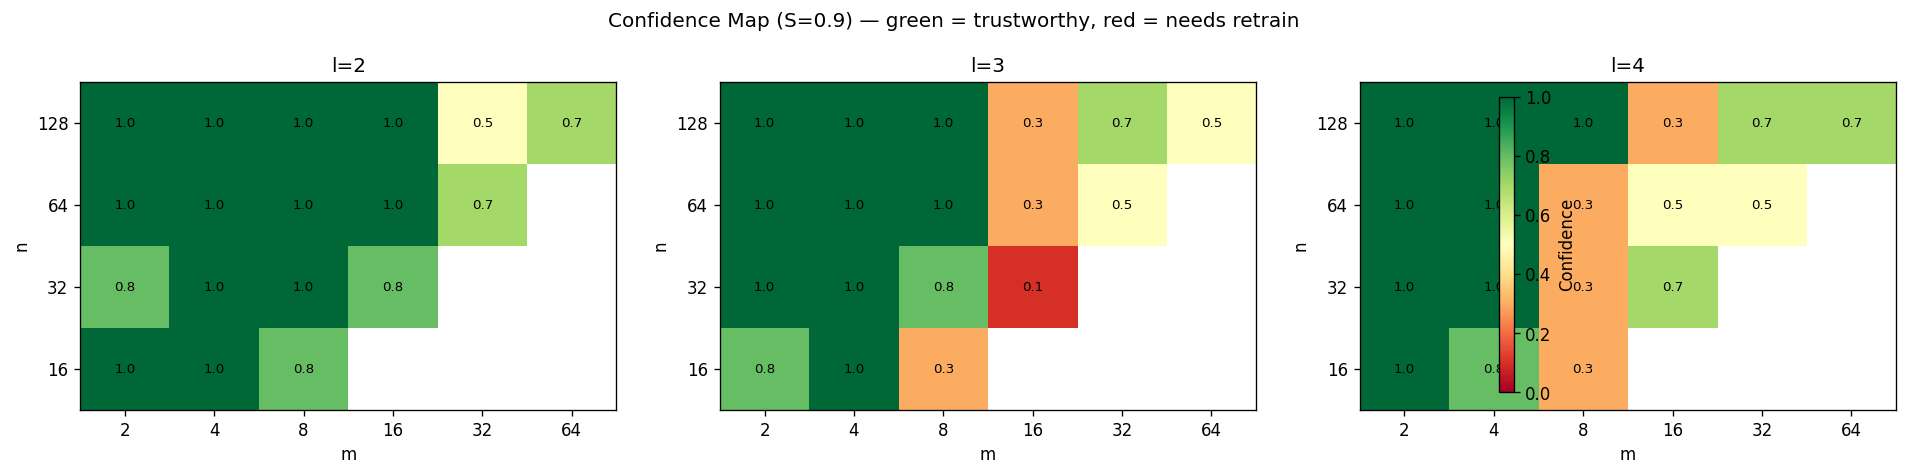

High confidence (≥0.8): 100 / 162 (62%)
Low confidence (<0.5): 47 / 162 (29%)

Low-confidence configs that matter (gain might change the phase diagram):
  n  m  l    S  nonlinear_gain  gain_mean  gain_std  confidence
 32 16  3 0.90        0.329974   0.109598  0.129990         0.1
 16  8  4 0.90        0.106262   0.072653  0.084685         0.3
 32  8  4 0.95        0.444479   0.045055  0.120812         0.3
 64 16  3 0.95        0.484396   0.042326  0.133316         0.3
 64 32  3 0.85        0.387523   0.081267  0.085762         0.3
128 16  3 0.90        0.316340   0.042303  0.083640         0.3
128 16  4 0.90        0.226347   0.020447  0.062104         0.3
 16  8  2 0.95        0.319066   0.162793  0.093320         0.5
 16  8  4 0.95        0.054186   0.017486  0.018752         0.5
 32 16  4 0.85        0.037431   0.015169  0.015298         0.5
 64 16  4 0.90        0.027836   0.026412  0.046831         0.5
128 16  3 0.85        0.498716   0.266011  0.199579         0.5
128 16  4 0.85 

In [12]:
# Confidence metric: combine CV, convergence rate, and neighbor consistency
df_nl = df_nl.copy()
df_nl['confidence'] = 1.0

# Penalize high CV
df_nl.loc[df_nl['cv'] > 0.5, 'confidence'] -= 0.3
df_nl.loc[df_nl['cv'] > 1.0, 'confidence'] -= 0.2

# Penalize low convergence rate
df_nl['conv_rate'] = df_nl['n_converged'] / df_nl['n_seeds']
df_nl.loc[df_nl['conv_rate'] < 0.5, 'confidence'] -= 0.2

# Penalize if best seed is far from mean (lucky seed)
excess = df_nl['nonlinear_gain'] - df_nl['gain_mean']
df_nl.loc[excess > 0.2, 'confidence'] -= 0.2

df_nl['confidence'] = df_nl['confidence'].clip(lower=0.1)

# Confidence heatmap at S=0.9
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for j, l in enumerate([2, 3, 4]):
    ax = axes[j]
    sub = df_nl[(df_nl.S == 0.9) & (df_nl.l == l)]
    
    grid = np.full((len(n_vals), len(m_vals)), np.nan)
    for _, row in sub.iterrows():
        ni = n_vals.index(row['n'])
        mi = m_vals.index(row['m'])
        grid[ni, mi] = row['confidence']
    
    im = ax.imshow(grid, cmap='RdYlGn', vmin=0, vmax=1,
                   aspect='auto', origin='lower')
    for ni, n in enumerate(n_vals):
        for mi, m in enumerate(m_vals):
            if not np.isnan(grid[ni, mi]):
                ax.text(mi, ni, f'{grid[ni, mi]:.1f}', ha='center', va='center', fontsize=8)
    
    ax.set_xticks(range(len(m_vals)))
    ax.set_xticklabels(m_vals)
    ax.set_yticks(range(len(n_vals)))
    ax.set_yticklabels(n_vals)
    ax.set_xlabel('m')
    ax.set_ylabel('n')
    ax.set_title(f'l={l}')

fig.suptitle('Confidence Map (S=0.9) — green = trustworthy, red = needs retrain', fontsize=12)
fig.colorbar(im, ax=axes, label='Confidence', shrink=0.8)
plt.tight_layout()
plt.show()

# Summary
low_conf = df_nl[df_nl.confidence < 0.5]
high_conf = df_nl[df_nl.confidence >= 0.8]
print(f'High confidence (≥0.8): {len(high_conf)} / {len(df_nl)} ({100*len(high_conf)/len(df_nl):.0f}%)')
print(f'Low confidence (<0.5): {len(low_conf)} / {len(df_nl)} ({100*len(low_conf)/len(df_nl):.0f}%)')
print()
print('Low-confidence configs that matter (gain might change the phase diagram):')
# These are the ones in the transition zone
matters = low_conf[(low_conf.nonlinear_gain > 0.01) & (low_conf.nonlinear_gain < 0.5)]
if len(matters) > 0:
    print(matters[['n','m','l','S','nonlinear_gain','gain_mean','gain_std','confidence']]
          .sort_values('confidence').to_string(index=False))
else:
    print('None — low-confidence configs are all clearly in one phase or the other')

## 9. Summary: What the Phase Diagram Says

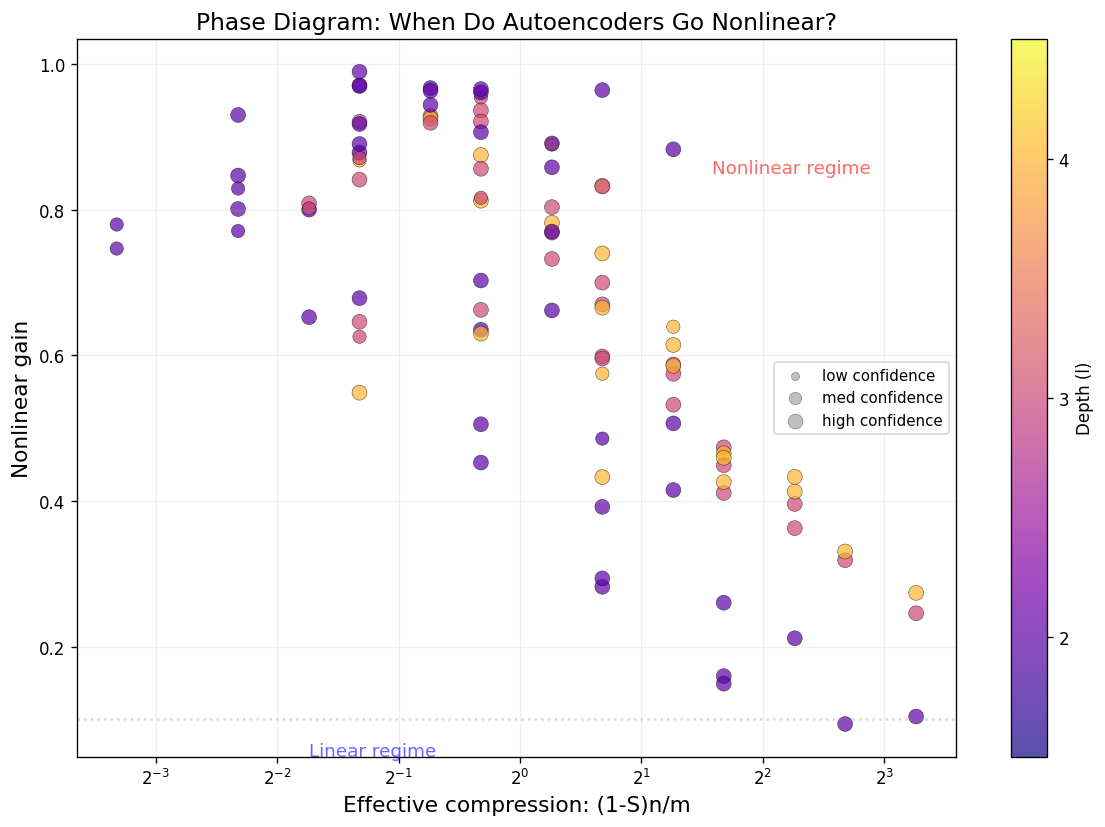

=== KEY FINDINGS ===

1. Nonlinear encoding emerges in 99/100 reliable configs (99%)
2. Effective ratio (1-S)n/m: Spearman r=-0.728 vs raw n/m: r=-0.756
3. Median gain at l=2: 0.775
3. Median gain at l=3: 0.700
3. Median gain at l=4: 0.614
4. l=4 < l=2 in 32/52 configs (likely optimization, not architecture)
5. High gain (>0.5) with linear encoder (score>0.95): 8 configs
   High gain (>0.5) with nonlinear encoder (score<0.8): 52 configs


In [13]:
# Final summary visualization: the "money plot"
fig, ax = plt.subplots(figsize=(10, 7))

rel = df_nl[df_nl.reliable].copy()

sc = ax.scatter(rel['eff_ratio'], rel['nonlinear_gain'],
               c=rel['l'], cmap='plasma', vmin=1.5, vmax=4.5,
               s=rel['confidence'] * 80, alpha=0.7,
               edgecolors='black', linewidths=0.3)

ax.set_xscale('log', base=2)
ax.set_xlabel('Effective compression: (1-S)n/m', fontsize=13)
ax.set_ylabel('Nonlinear gain', fontsize=13)
ax.set_title('Phase Diagram: When Do Autoencoders Go Nonlinear?', fontsize=14)
ax.grid(alpha=0.2)

# Annotate regions
ax.axhline(0.1, color='gray', ls=':', alpha=0.3)
ax.text(0.3, 0.05, 'Linear regime', fontsize=11, color='blue', alpha=0.6)
ax.text(3, 0.85, 'Nonlinear regime', fontsize=11, color='red', alpha=0.6)

cbar = plt.colorbar(sc, label='Depth (l)')
cbar.set_ticks([2, 3, 4])

# Size legend
for conf, size in [(0.3, 'low'), (0.7, 'med'), (1.0, 'high')]:
    ax.scatter([], [], s=conf*80, c='gray', alpha=0.5, edgecolors='black', linewidths=0.3,
             label=f'{size} confidence')
ax.legend(fontsize=9, loc='center right')

plt.tight_layout()
plt.show()

# Key takeaways as text
print('=== KEY FINDINGS ===')
print()

rel_above = rel[rel.nonlinear_gain > 0.1]
print(f'1. Nonlinear encoding emerges in {len(rel_above)}/{len(rel)} reliable configs ({100*len(rel_above)/len(rel):.0f}%)')

r_nm, _ = stats.spearmanr(rel['n_over_m'], rel['nonlinear_gain'])
r_eff, _ = stats.spearmanr(rel['eff_ratio'], rel['nonlinear_gain'])
print(f'2. Effective ratio (1-S)n/m: Spearman r={r_eff:.3f} vs raw n/m: r={r_nm:.3f}')

median_gains = []
for l in [2, 3, 4]:
    mg = rel[rel.l == l]['nonlinear_gain'].median()
    median_gains.append(mg)
    print(f'3. Median gain at l={l}: {mg:.3f}')

print(f'4. l=4 < l=2 in {(dr[dr.l==4]["ratio"] < 1).sum()}/{len(dr[dr.l==4])} configs (likely optimization, not architecture)')
print(f'5. High gain (>0.5) with linear encoder (score>0.95): {len(high_gain_linear)} configs')
print(f'   High gain (>0.5) with nonlinear encoder (score<0.8): {len(high_gain_nonlinear)} configs')